# Investigate HMO companies

In [96]:
import json

import pandas as pd

import sqlite3

In [97]:
conn = sqlite3.connect("search_data_by_company_number.db")
hmo_conn = sqlite3.connect("hmo_companies.db")

df = pd.read_sql_query("SELECT * FROM search_data_by_company_number", conn)
hmos = pd.read_sql_query("SELECT company_number, filename FROM hmo_companies", hmo_conn)
hmos['is_hmo_company'] = hmos['filename'].apply(bool)
hmos.drop(columns=['filename'])

df = df.merge(hmos, on='company_number', how='left')

In [98]:
df['officer_appointed_on'] = pd.to_datetime(df['officer_appointed_on'].apply(lambda x: '' if x[:6]=="before" else x), format='mixed')
df['officer_resigned_on'] = pd.to_datetime(df['officer_resigned_on'])

In [99]:
df

,company_number,company_name,company_status,officer_id,office_name,officer_role,officer_appointed_on,officer_status,officer_resigned_on,filename,is_hmo_company
0,SC317107,1LET LIMITED,active,P2nJGdD7q4sgW3hoBvuYmo_mM6Y,"BELL, Natalie",secretary,2023-03-01,active,NaT,1let.html,True
1,SC317107,1LET LIMITED,active,AYv6oPcd4be3GSlR4RtnETs0prg,"BELL, Kenneth",director,2017-10-02,resigned,2019-02-19,1let.html,True
2,SC317107,1LET LIMITED,active,qjh18tO1oRibYi-y361gBrIEnnc,"MCLEAN-FOREMAN, Fiona Mary",director,2007-02-22,resigned,2021-12-17,1let.html,True
3,SC317107,1LET LIMITED,active,BwTBFPU7PuErIdu02TKIf4f53uI,"MCLEAN-FOREMAN, Ewan Laing",director,2007-02-22,resigned,2021-12-17,1let.html,True
4,SC317107,1LET LIMITED,active,_u8ObkxBRAUeaoozc2mlFbb_MZE,"WHORISKEY, Brigid",director,2017-10-02,resigned,2017-10-02,1let.html,True
...,...,...,...,...,...,...,...,...,...,...,...
38216,00615420,J.B.HOWARD PROPERTIES LIMITED,active,1iT8lzZch0srlT5UgHYfo-jl4dQ,Comrun SOBHANPANAH,director,2012-06-15,resigned,2012-06-15,NaN,NaN
38217,10889692,BETHEAIR LTD,dissolved,1jqNViUMV0XlzmxIY9Ori4LnhVA,Arunas MALINAUSKAS,director,2017-07-28,resigned,2019-08-30,NaN,NaN
38218,12318580,NAFEE & NAWAR CONSULTANCY SERVICES LTD,active,1oBkyBpQ-7NhNlMAoMbwDtb0T7A,Nafee Arham KHANDKAR,director,2024-12-10,active,NaT,NaN,NaN
38219,14972841,ALEXANDER GREENS PROPERTY SERVICES (HUNTINGDON...,dissolved,1s8JJ5POoLk435-ZxumZ8a_HI1U,Nabila SHEIKH,director,2023-06-30,inactive,NaT,NaN,NaN


In [100]:
## QA Steps for notebook

## Remove all rows showing an officer which resigned within a year of appointment
df = df[(df['officer_status'] != "resigned") | (df['officer_appointed_on'] + pd.DateOffset(years=1) < df['officer_resigned_on'])]

## Only non-corporate members
df = df[~df['officer_role'].str.startswith("corporate")]

## merge companies which have an identical set of officers into one company
## We assume that there are not gaps in the total activity period of an officer in these companies

# Use an unambiguous, deterministic string as the signature for each set of officers.
company_officer_groups = (
    df.groupby('company_number', as_index=False, sort=False)
      .agg(
          officer_group=(
              'officer_id',
              lambda officer_ids: json.dumps(
                  sorted(officer_ids.dropna().unique()),
                  separators=(',', ':'),
              ),
          )
      )
)

df = df.merge(
    company_officer_groups,
    on='company_number',
    how='left',
    validate='many_to_one',
)

# Select one representative company per officer group. Prefer HMO companies,
# then active companies, then the company with the latest known appointment date. The final sort key
# makes ties deterministic and preserves groups whose dates are all NaT.
representative_companies = (
    df.groupby(
        ['officer_group', 'company_number', 'company_name', 'company_status', 'is_hmo_company'],
        as_index=False,
        sort=False,
        dropna=False,
    )
      .agg(latest_officer_appointed_on=('officer_appointed_on', 'max'))
      .assign(is_active=lambda companies: companies['company_status'].eq('active'))
      .sort_values(
          ['officer_group', 'is_hmo_company', 'is_active', 'latest_officer_appointed_on', 'company_number'],
          ascending=[True, False, False, False, True],
          na_position='last',
      )
      .drop_duplicates('officer_group')
      [['officer_group', 'company_number', 'company_name', 'company_status']]
)

officer_group_sizes = (
    df.groupby('officer_group', as_index=False, sort=False)
      .agg(n_duplicate_companies=('company_number', 'nunique'))
)

status_priority = {'active': 0, 'inactive': 1, 'resigned': 2}
merged_officers = (
    df.groupby(
        ['officer_group', 'officer_id', 'office_name'],
        as_index=False,
        sort=False,
        dropna=False,
    )
      .agg(
          officer_role=(
              'officer_role',
              lambda roles: ', '.join(sorted(roles.dropna().unique())),
          ),
          officer_appointed_on=(
              'officer_appointed_on',
              lambda dates: dates.min(skipna=False),
          ),
          officer_status=(
              'officer_status',
              lambda statuses: min(
                  statuses.dropna(),
                  key=lambda status: status_priority.get(status, len(status_priority)),
              ),
          ),
          officer_resigned_on=(
              'officer_resigned_on',
              lambda dates: dates.min(skipna=False),
          ),
      )
)

df = (
    merged_officers
      .merge(
          representative_companies,
          on='officer_group',
          how='left',
          validate='many_to_one',
      )
      .merge(
          officer_group_sizes,
          on='officer_group',
          how='left',
          validate='many_to_one',
      )
      [[
          'company_number', 'company_name', 'company_status',
          'officer_id', 'office_name', 'officer_role',
          'officer_appointed_on', 'officer_status', 'officer_resigned_on',
          'officer_group', 'n_duplicate_companies',
      ]]
)

## Active companies
df = df[df['company_status'] == 'active'].reset_index(drop=True)


In [101]:
df['officer_role'].value_counts()

officer_role
director                                       1824
secretary                                       224
llp-designated-member                            51
llp-member                                       38
director, secretary                               8
director, llp-designated-member                   5
director, llp-member                              3
director, llp-designated-member, secretary        2
director, llp-designated-member, llp-member       1
Name: count, dtype: int64

In [102]:
import networkx as nx

df_edges = df.merge(df, on='officer_id', suffixes=("_1", "_2")).query('company_number_1 < company_number_2').drop_duplicates()

G = nx.from_pandas_edgelist(
    df_edges,
    source='company_number_1',
    target='company_number_2'
)

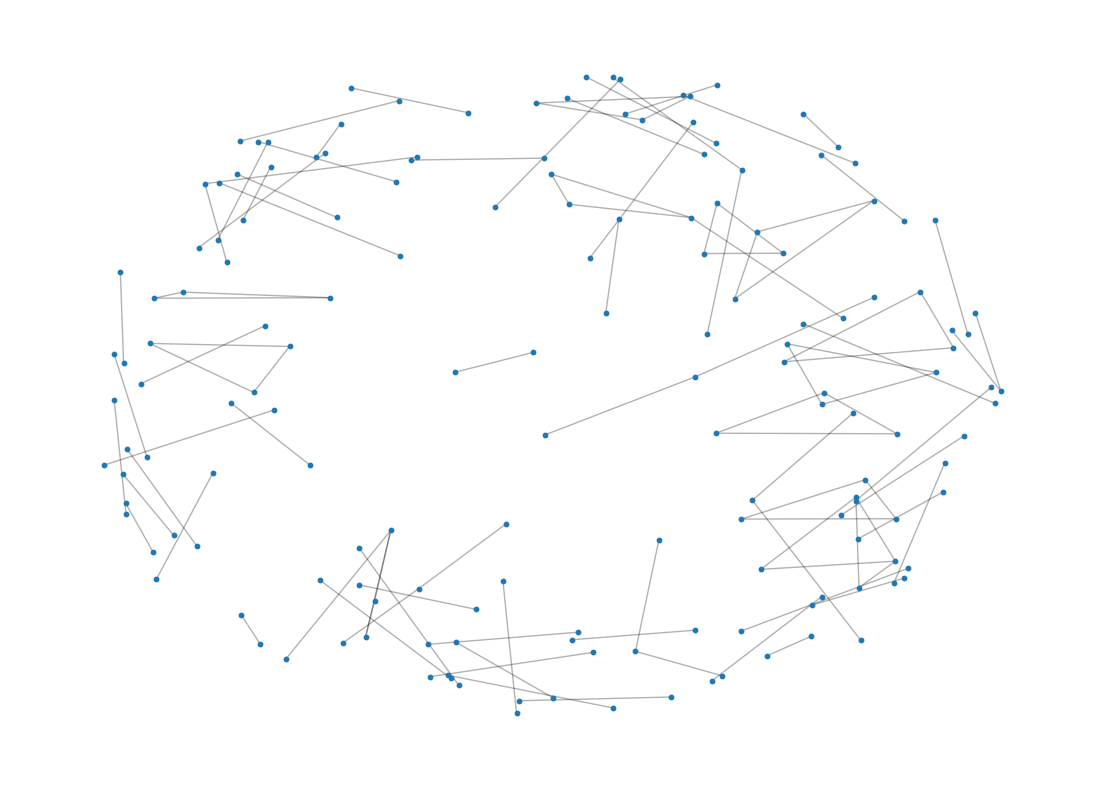

In [103]:
import matplotlib.pyplot as plt
import networkx as nx

plt.figure(figsize=(14, 10))

pos = nx.spring_layout(G, seed=42, k=0.4)

nx.draw_networkx_nodes(G, pos, node_size=10)
nx.draw_networkx_edges(G, pos, alpha=0.3)
# nx.draw_networkx_labels(G, pos, font_size=8)

plt.axis("off")
plt.show()

In [104]:
# Aggregate each company's officers, then identify subset relationships.
company_officers = (
    df.groupby(['company_number', 'company_name'], as_index=False)
      .agg(officers=('officer_id', lambda ids: set(ids.dropna())))
)

subset_cases = []
for left_index, left in company_officers.iterrows():
    for _, right in company_officers.iloc[left_index + 1:].iterrows():
        if left['officers'] == right['officers']:
            subset_company, superset_company = left, right
        elif left['officers'] < right['officers']:
            subset_company, superset_company = left, right
        elif right['officers'] < left['officers']:
            subset_company, superset_company = right, left
        else:
            continue

        subset_cases.append({
            'subset_company_number': subset_company['company_number'],
            'subset_company_name': subset_company['company_name'],
            'superset_company_number': superset_company['company_number'],
            'superset_company_name': superset_company['company_name'],
            'subset_officers': subset_company['officers'],
            'superset_officers': superset_company['officers'],
            'additional_officers': superset_company['officers'] - subset_company['officers'],
        })

company_officer_subset_cases = pd.DataFrame(subset_cases)
company_officer_subset_cases

,subset_company_number,subset_company_name,superset_company_number,superset_company_name,subset_officers,superset_officers,additional_officers
0,00336779,APPLE GROWERS ASSOCIATION (WEST KENT) LIMITED,03220747,BLUE RHAPSODY LIMITED,{12Hx9J6hWEjvkV08cmbixhHUDXU},"{12Hx9J6hWEjvkV08cmbixhHUDXU, ZWuHmkekUp142thT...","{ZWuHmkekUp142thTj16DHwF8NvU, jEpSdr78wIrG6ULa..."
1,SC092749,ALLOA COMMUNITY ENTERPRISES LIMITED,00482023,TAPTON ESTATES LIMITED,{0ppmAyWfwMz_cnpj2slavZXZaJY},"{e05mSDOyPfg4mj5FzlCAvxFh1Oc, t5qzqDcGtPcnwcTw...","{e05mSDOyPfg4mj5FzlCAvxFh1Oc, t5qzqDcGtPcnwcTw..."
2,00897907,PROPERTYMARK LTD,02798775,THE ASSOCIATION OF RESIDENTIAL LETTING AGENTS,{-1Hw2P6DO_bmTL3el-D7i9C5Ops},"{LmbyeTBpHw8jNk6Y8N0AWP2ynOE, D6W7CQIXVmNFUb66...","{LmbyeTBpHw8jNk6Y8N0AWP2ynOE, D6W7CQIXVmNFUb66..."
3,01286309,FIRSTPORT PROPERTY SERVICES NO.16 LIMITED,05393722,CHASE BUCHANAN GROUP LIMITED,{1RZouidXNKzKXz01IQBsknATvgM},"{hO_WeXq6zRi_IxK55sRNkTe7Myw, bua5_xn7lVv-xcFW...","{hO_WeXq6zRi_IxK55sRNkTe7Myw, bua5_xn7lVv-xcFW..."
4,01324797,CASTLEHILL INVESTMENTS LIMITED,05561246,CASTLEHILL ESTATE AGENTS LIMITED,{0fUz-sJxBgfiqKX5jNvVBiIip2M},"{kutszoq6CNFREr0BbMQFqkIBLR0, TFUlpSaRct4EOsrP...","{BONOuPO8XhjSpbMKHNubIHC27VY, kutszoq6CNFREr0B..."
...,...,...,...,...,...,...,...
56,NI036168,FORWARD SOUTH PARTNERSHIP,NI610795,S U LETS LIMITED,{1FU5LQCElKfFVv1FKAMr7K8Vh5M},"{4Fspx-zHS7Jtcbngm5Tm5EB030I, 1FU5LQCElKfFVv1F...","{f_Ugb05yvRBVbUbdAUte0XX66-8, I-bV_e4uJVYH6eVN..."
57,NI611653,BELFAST STUDENT PROPERTY INVESTMENT COMPANY LI...,NI611651,BELFAST STUDENT ACCOMMODATION LIMITED,{-9yKK29sdfsWRUyyTP2opnHSdGI},"{hMysPHPpHFo-5N1DjhmD0VtSsEI, -9yKK29sdfsWRUyy...","{hMysPHPpHFo-5N1DjhmD0VtSsEI, 7tkKFkocuaA4bv7U..."
58,SC237007,J & E NOMINEES LIMITED,SC175211,DIRECT LETTINGS (SCOTLAND) LIMITED,{1f6EL9JJXwUpSswy02zGewIa_xc},"{k1N58Jp95zjk9f41K9eoIJ66gEM, fD-oV7Ppo-xdKGET...","{k1N58Jp95zjk9f41K9eoIJ66gEM, fD-oV7Ppo-xdKGET..."
59,SC642439,RE-GROUP LETTING LTD,SC363049,GLENHAM PROPERTY MANAGEMENT LTD,{1avHfBd4LQM0OqytBK8cQkwnvng},"{1avHfBd4LQM0OqytBK8cQkwnvng, lvyXrB8gDRk_HrgO...",{lvyXrB8gDRk_HrgOt9p84PdUhlU}


In [107]:
conn = sqlite3.connect("search_data_by_company_number.db")
pd.read_sql_query("SELECT * FROM sqlite_master", con=conn)

,type,name,tbl_name,rootpage,sql
